# 04 — Loan-age transitions & early-warning segments

**Plain English:** Two monitoring views.

**Loan-age transition view** — *when* do charge-offs happen? SBA data is outcome-level (one final status per loan), not a monthly grade panel, so a true monthly migration matrix isn't possible here (that lives in the companion Freddie Mac monitor). The feasible substitute: bucket charge-offs by the loan age at which they occurred.

**Early-warning segmentation** — which **industry × vintage × size** segments are charging off well above the portfolio average? We only flag segments large enough to be meaningful, so one unlucky loan can't trip it.

In [1]:
%matplotlib inline
import sys, warnings
from pathlib import Path
warnings.filterwarnings('ignore')
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))
import pandas as pd
pd.set_option('display.max_columns', 40, 'display.width', 200)
from src.config import load_config, TABLES_DIR
CFG = load_config()

In [2]:
from src.data_loader import load_clean
from src.base_table import build_base_table
loans = load_clean(config=CFG)
base = build_base_table(loans, config=CFG)
print(f'{len(base):,} funded loans, vintages {int(base.vintage.min())}-{int(base.vintage.max())}')

[2026-06-25 13:11:05] [INFO    ] [data_loader] Loading 2 SBA input file(s): ['foia-7a-fy2000-fy2009-asof-260331.csv', 'foia-7a-fy2010-fy2019-asof-260331.csv']


[2026-06-25 13:11:08] [INFO    ] [data_loader]   foia-7a-fy2000-fy2009-asof-260331.csv -> 690333 rows


[2026-06-25 13:11:11] [INFO    ] [data_loader]   foia-7a-fy2010-fy2019-asof-260331.csv -> 545751 rows


[2026-06-25 13:11:11] [INFO    ] [data_loader] Combined raw frame: 1236084 rows


[2026-06-25 13:11:14] [INFO    ] [data_loader] Dropped 149065 never-funded loans (['CANCLD', 'COMMIT']); 1087019 funded loans remain


[2026-06-25 13:11:16] [INFO    ] [base_table] Base table built: 1087019 loans, 20 vintages (2000-2019), 132662 defaults, 9805 problem exposures


1,087,019 funded loans, vintages 2000-2019


In [3]:
from src import transitions
from src.early_warning import flag_high_risk_segments
from src.charts import plot_loan_age_transition
age = transitions.loan_age_transition(base)
ew = flag_high_risk_segments(base, config=CFG)
age.to_csv(TABLES_DIR / '04_loan_age_transitions.csv', index=False)
ew.to_csv(TABLES_DIR / '04_early_warning_segments.csv', index=False)

[2026-06-25 13:11:16] [INFO    ] [transitions] Loan-age transition view: 117652 charge-offs across 874286 seasoned loans


[2026-06-25 13:11:16] [INFO    ] [early_warning] Early warning: 115 segments flagged (portfolio rate 13.46%, >= 1.5x threshold, min 200 loans)


### Result: when charge-offs occur, by loan age (seasoned vintages)

In [4]:
age

,loan_age_band,chargeoffs,pct_of_chargeoffs,cumulative_pct_of_chargeoffs,pct_of_portfolio
0,0-12m,960,0.0082,0.0082,0.0011
1,12-24m,11261,0.0957,0.1039,0.0129
2,24-36m,18970,0.1612,0.2651,0.0217
3,36-48m,22178,0.1885,0.4536,0.0254
4,48-60m,18422,0.1566,0.6102,0.0211
5,60-84m,23878,0.2030,0.8132,0.0273
6,84-120m,14855,0.1263,0.9395,0.0170
7,120m+,7128,0.0606,1.0001,0.0082


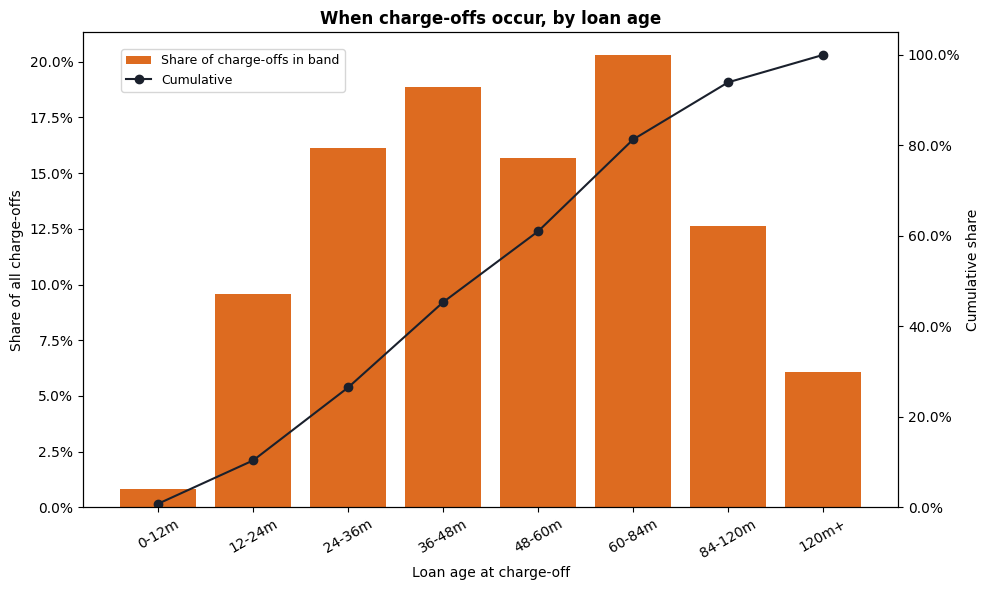

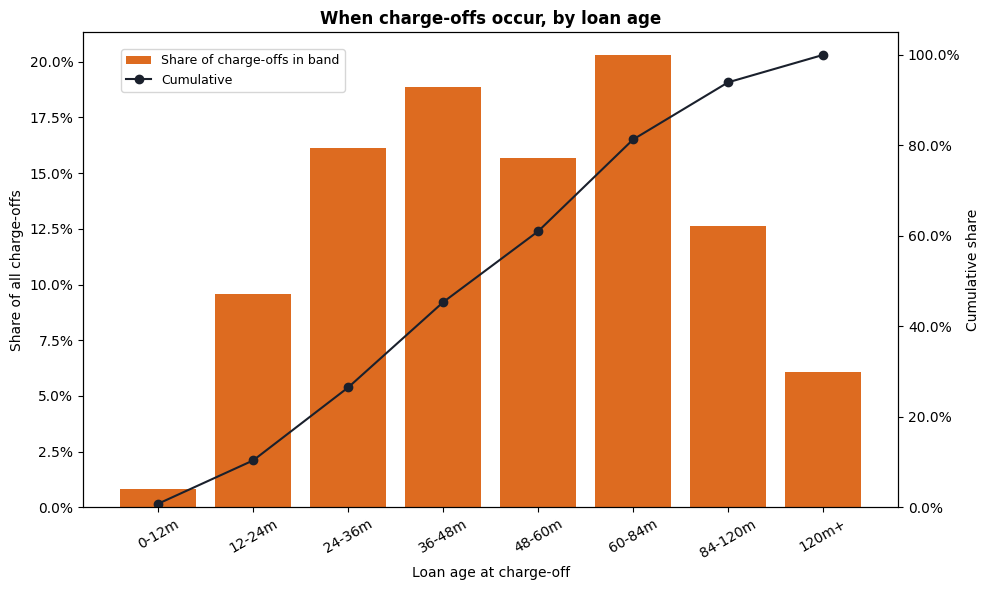

In [5]:
plot_loan_age_transition(age)

#### Early-warning segments — worst 15 by multiple of portfolio rate

In [6]:
ew.head(15)

,industry,vintage,size_band,loan_count,defaults,exposure,chargeoff_rate,portfolio_rate,rate_multiple,severity
0,Real Estate & Rental & Leasing,2007,<=50k,1978,838,55259100.0,0.4237,0.1346,3.15,High
1,Wholesale Trade,2007,<=50k,2763,1066,83956535.0,0.3858,0.1346,2.87,High
2,Wholesale Trade,2008,<=50k,1590,591,49093100.0,0.3717,0.1346,2.76,High
3,Finance & Insurance,2007,<=50k,1308,484,36247800.0,0.3700,0.1346,2.75,High
4,Wholesale Trade,2007,50k-150k,1198,432,119134050.0,0.3606,0.1346,2.68,High
5,Real Estate & Rental & Leasing,2007,50k-150k,379,133,36083000.0,0.3509,0.1346,2.61,High
6,Wholesale Trade,2006,50k-150k,1245,431,124140988.0,0.3462,0.1346,2.57,High
7,Finance & Insurance,2007,50k-150k,258,89,24700300.0,0.3450,0.1346,2.56,High
8,Real Estate & Rental & Leasing,2006,50k-150k,352,120,34111700.0,0.3409,0.1346,2.53,High
9,Real Estate & Rental & Leasing,2008,<=50k,959,327,26052200.0,0.3410,0.1346,2.53,High


**Read-out:** most charge-offs land in the **2–5 year** window after approval (early-life defaults are rare, then risk peaks). The flagged segments are dominated by **2007–2008 crisis vintages in small loans** across wholesale, real estate and finance — exactly where you'd tighten.